In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 

Data Understanding

In [2]:
df=pd.read_csv('netflix1.csv')
df.head(10)
df.tail(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8780,s8759,TV Show,World's Busiest Cities,Not Given,United Kingdom,2/1/2019,2017,TV-PG,1 Season,"British TV Shows, Docuseries"
8781,s8776,TV Show,Yeh Meri Family,Not Given,India,8/31/2018,2018,TV-PG,1 Season,"International TV Shows, TV Comedies"
8782,s8781,TV Show,Yo-Kai Watch,Not Given,United States,4/1/2016,2015,TV-Y7,1 Season,"Anime Series, Kids' TV"
8783,s8785,Movie,Yoko and His Friends,Not Given,Russia,6/23/2018,2015,TV-Y,78 min,Children & Family Movies
8784,s8796,TV Show,Yu-Gi-Oh! Arc-V,Not Given,Japan,5/1/2018,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV"
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [3]:
df.shape

(8790, 10)

In [4]:
df.dtypes

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [6]:
df.describe(include=['object'])


,show_id,type,title,director,country,date_added,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8787,4528,86,1713,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,3205,1791,362


In [7]:
df.describe(include=['O']) 

,show_id,type,title,director,country,date_added,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8787,4528,86,1713,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,3205,1791,362


In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

Data Cleaning 

In [9]:
df.isnull().sum()


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

show_id         8790
type               2
title           8787
director        4528
country           86
date_added      1713
release_year      74
rating            14
duration         220
listed_in        513
dtype: int64

In [12]:
df['date_added']=pd.to_datetime(df['date_added'])
df['date_added'].head(10)


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-22
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-05-01
8   2021-09-23
9   2021-05-01
Name: date_added, dtype: datetime64[ns]

In [13]:

df.columns=df.columns.str.upper()
df.columns
df.head()


,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [14]:
df['SHOW_ID'].str.upper()

0          S1
1          S3
2          S6
3         S14
4          S8
        ...  
8785    S8797
8786    S8798
8787    S8801
8788    S8784
8789    S8786
Name: SHOW_ID, Length: 8790, dtype: object

In [15]:
tv_shows = df[df['TYPE'] == 'TV Show']
print(tv_shows.head())


   SHOW_ID     TYPE                            TITLE         DIRECTOR  \
1       s3  TV Show                        Ganglands  Julien Leclercq   
2       s6  TV Show                    Midnight Mass    Mike Flanagan   
5       s9  TV Show    The Great British Baking Show  Andy Devonshire   
17      s4  TV Show            Jailbirds New Orleans        Not Given   
18     s15  TV Show  Crime Stories: India Detectives        Not Given   

           COUNTRY DATE_ADDED  RELEASE_YEAR RATING   DURATION  \
1           France 2021-09-24          2021  TV-MA   1 Season   
2    United States 2021-09-24          2021  TV-MA   1 Season   
5   United Kingdom 2021-09-24          2021  TV-14  9 Seasons   
17        Pakistan 2021-09-24          2021  TV-MA   1 Season   
18        Pakistan 2021-09-22          2021  TV-MA   1 Season   

                                            LISTED_IN  
1   Crime TV Shows, International TV Shows, TV Act...  
2                  TV Dramas, TV Horror, TV Mysteries  
5 

In [16]:
movies=df[df['TYPE']=='Movie']
movies.head(10)

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,2021-05-01,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"
10,s941,Movie,Motu Patlu: Deep Sea Adventure,Suhas Kadav,India,2021-05-01,2014,TV-Y7,76 min,"Children & Family Movies, Comedies"
11,s942,Movie,Motu Patlu: Mission Moon,Suhas Kadav,India,2021-05-01,2013,TV-Y7,71 min,"Children & Family Movies, Comedies"
12,s852,Movie,99 Songs (Tamil),Not Given,Pakistan,2021-05-21,2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals"


In [17]:
df.head()
Release_Period = df[df['RELEASE_YEAR'] == 2015]
Release_Period.head()


,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
170,s117,Movie,Dhanak,Nagesh Kukunoor,India,2021-09-02,2015,TV-PG,114 min,"Comedies, Dramas, Independent Movies"
184,s134,Movie,Chappie,Neill Blomkamp,South Africa,2021-09-01,2015,R,121 min,"Action & Adventure, Sci-Fi & Fantasy"
203,s142,Movie,Extraction,Steven C. Miller,United States,2021-09-01,2015,R,82 min,Action & Adventure
245,s174,Movie,Snervous Tyler Oakley,Amy Rice,United States,2021-09-01,2015,PG-13,83 min,"Documentaries, LGBTQ Movies"
284,s2569,TV Show,Hangar 1: The UFO Files,Not Given,Pakistan,2020-05-02,2015,TV-PG,1 Season,Docuseries


In [18]:
List_of_Tvshows=df[df['TYPE']=='TV Show']
List_of_Tvshows.head(10)


,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
17,s4,TV Show,Jailbirds New Orleans,Not Given,Pakistan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
18,s15,TV Show,Crime Stories: India Detectives,Not Given,Pakistan,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries"
20,s4832,TV Show,True: Magical Friends,"Mark Thornton, Todd Kauffman",United States,2018-06-15,2018,TV-Y,1 Season,Kids' TV
21,s4833,TV Show,True: Wonderful Wishes,"Mark Thornton, Todd Kauffman",United States,2018-06-15,2018,TV-Y,1 Season,Kids' TV
22,s4857,TV Show,Dance & Sing with True,"Mark Thornton, Todd Kauffman",United States,2018-05-18,2018,TV-Y,1 Season,Kids' TV
24,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,Not Given,2021-09-23,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
27,s21,TV Show,Monsters Inside: The 24 Faces of Billy Milligan,Olivier Megaton,United States,2021-09-22,2021,TV-14,1 Season,"Crime TV Shows, Docuseries, International TV S..."


In [19]:
Indian_Shows=df[df['COUNTRY']=='India']
Indian_Shows.head(10)


,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,2021-05-01,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"
10,s941,Movie,Motu Patlu: Deep Sea Adventure,Suhas Kadav,India,2021-05-01,2014,TV-Y7,76 min,"Children & Family Movies, Comedies"
11,s942,Movie,Motu Patlu: Mission Moon,Suhas Kadav,India,2021-05-01,2013,TV-Y7,71 min,"Children & Family Movies, Comedies"
29,s25,Movie,Jeans,S. Shankar,India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies"
51,s27,Movie,Minsara Kanavu,Rajiv Menon,India,2021-09-21,1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals"
142,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,India,2021-09-05,2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas"
148,s115,Movie,Anjaam,Rahul Rawail,India,2021-09-02,1994,TV-14,143 min,"Dramas, International Movies, Thrillers"
170,s117,Movie,Dhanak,Nagesh Kukunoor,India,2021-09-02,2015,TV-PG,114 min,"Comedies, Dramas, Independent Movies"
172,s119,Movie,Gurgaon,Shanker Raman,India,2021-09-02,2017,TV-14,106 min,"Dramas, International Movies, Thrillers"


In [20]:
Rating_Category=df[df['RATING']=='TV-MA']
Rating_Category.head(10)

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies"
14,s730,Movie,Bling Empire - The Afterparty,"Krysia Plonka, Kristian Mercado",United States,2021-06-12,2021,TV-MA,36 min,Movies
15,s731,Movie,Cobra Kai - The Afterparty,"Krysia Plonka, Kristian Mercado",United States,2021-06-12,2021,TV-MA,34 min,Movies
17,s4,TV Show,Jailbirds New Orleans,Not Given,Pakistan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
18,s15,TV Show,Crime Stories: India Detectives,Not Given,Pakistan,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries"
24,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,Not Given,2021-09-23,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
25,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",Not Given,2021-09-22,2020,TV-MA,67 min,"Documentaries, International Movies"


In [21]:
Docmentraties=df[df['LISTED_IN']=='Documentaries']
Docmentraties.head()

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
80,s46,Movie,My Heroes Were Cowboys,Tyler Greco,Not Given,2021-09-16,2021,PG,23 min,Documentaries
110,s405,Movie,9to5: The Story of a Movement,Not Given,Pakistan,2021-07-22,2021,TV-MA,85 min,Documentaries
115,s1071,Movie,Why Did You Kill Me?,Fredrick Munk,United States,2021-04-14,2021,TV-MA,84 min,Documentaries
151,s718,Movie,Headspace: Unwind Your Mind,Not Given,Pakistan,2021-06-15,2021,TV-G,273 min,Documentaries


In [22]:
group_type=df.groupby('TYPE')['RELEASE_YEAR'].count()
print(group_type)

TYPE
Movie      6126
TV Show    2664
Name: RELEASE_YEAR, dtype: int64


In [23]:
df.groupby('COUNTRY')['RATING'].count().sort_values(ascending=False).head(10)

COUNTRY
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: RATING, dtype: int64

In [24]:
df.groupby('RELEASE_YEAR')['LISTED_IN'].count().sort_values(ascending=False).head(10)

RELEASE_YEAR
2018    1146
2017    1030
2019    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: LISTED_IN, dtype: int64

In [25]:
df.groupby(['COUNTRY','TYPE'])['SHOW_ID'].count().sort_values(ascending=False).head(10)

COUNTRY         TYPE   
United States   Movie      2395
India           Movie       976
United States   TV Show     845
United Kingdom  Movie       387
Pakistan        TV Show     350
Not Given       Movie       257
United Kingdom  TV Show     251
Canada          Movie       187
Japan           TV Show     172
South Korea     TV Show     165
Name: SHOW_ID, dtype: int64

In [26]:
latest_content = df.sort_values(by='DATE_ADDED', ascending=False).head(5)
latest_content

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas"
23,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Not Given,2021-09-24,2021,PG,91 min,Children & Family Movies
6572,s5,TV Show,Kota Factory,Not Given,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
6570,s2,TV Show,Blood & Water,Not Given,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"


In [27]:
oldest_content=df.sort_values(by='DATE_ADDED',ascending=False).head(5)
oldest_content


,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas"
23,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Not Given,2021-09-24,2021,PG,91 min,Children & Family Movies
6572,s5,TV Show,Kota Factory,Not Given,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
6570,s2,TV Show,Blood & Water,Not Given,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"


In [28]:
df.groupby('COUNTRY')['TITLE'].count().head(5)


COUNTRY
Argentina      76
Australia     114
Austria         9
Bangladesh      3
Belarus         1
Name: TITLE, dtype: int64

In [29]:
df.explode('LISTED_IN').head(5)

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [30]:
df.explode('COUNTRY').head(5)

,SHOW_ID,TYPE,TITLE,DIRECTOR,COUNTRY,DATE_ADDED,RELEASE_YEAR,RATING,DURATION,LISTED_IN
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [31]:
RANK=df.groupby('DURATION')['TITLE'].rank().sort_values(ascending=False).head(5)
RANK


8509    1791.0
459     1790.0
539     1789.0
287     1788.0
8321    1787.0
Name: TITLE, dtype: float64

In [32]:
pd.pivot_table(df,values='DURATION',index='TYPE',aggfunc='count')

,DURATION
TYPE,
Movie,6126
TV Show,2664


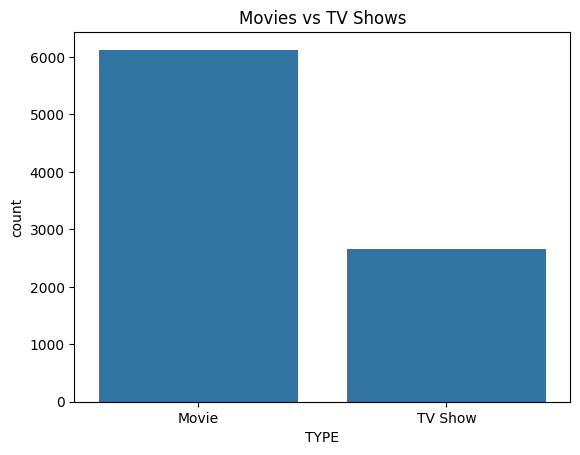

In [35]:
sns.countplot(x='TYPE',data=df)

plt.title("Movies vs TV Shows")

plt.show()

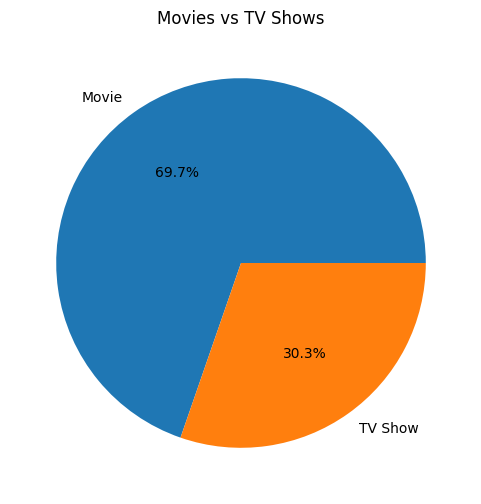

In [36]:
df['TYPE'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Movies vs TV Shows")

plt.ylabel('')

plt.show()

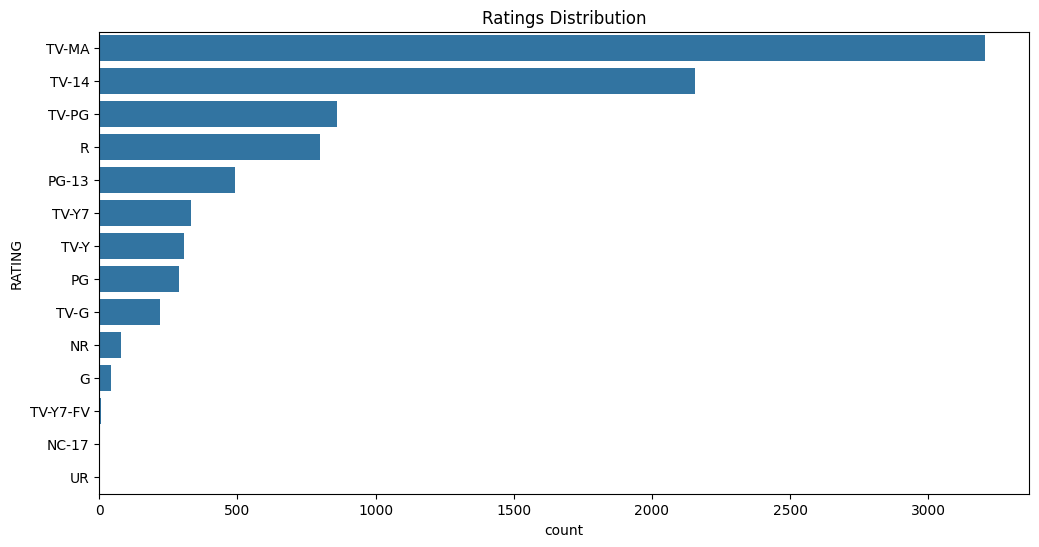

In [38]:

plt.figure(figsize=(12,6))

sns.countplot(
    y='RATING',
    data=df,
    order=df['RATING'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

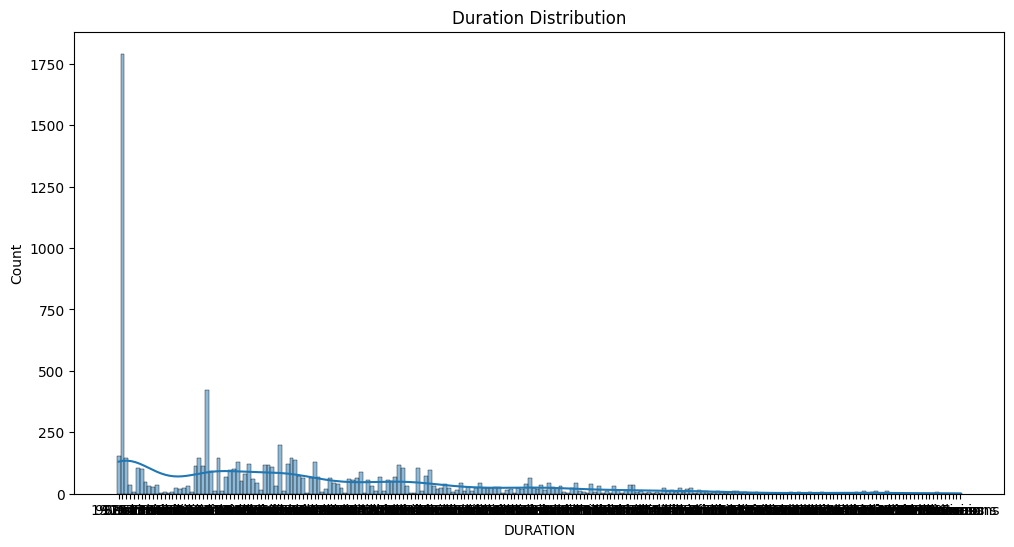

In [40]:
plt.figure(figsize=(12,6))

sns.histplot(df['DURATION'],bins=30,kde=True)

plt.title("Duration Distribution")

plt.show()

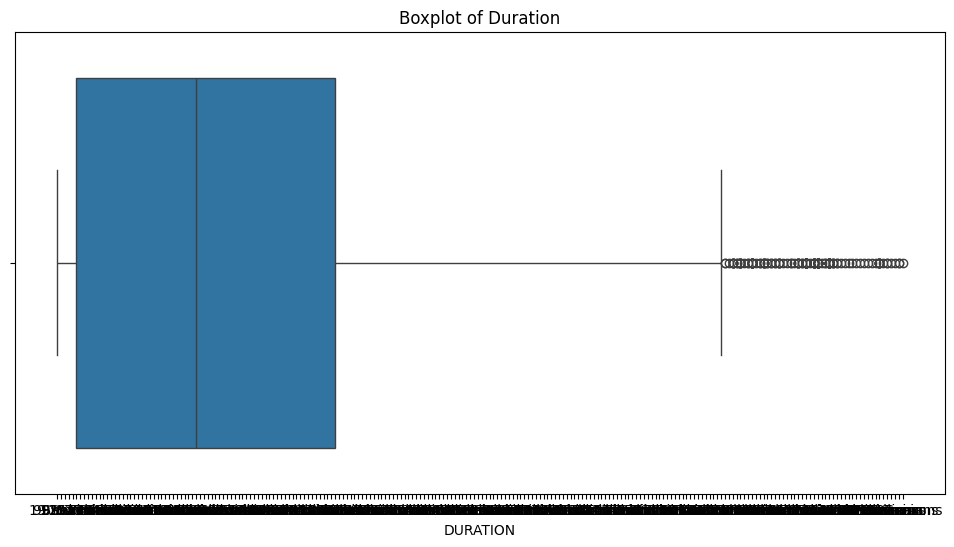

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x=df['DURATION'])
plt.title("Boxplot of Duration")
plt.show()

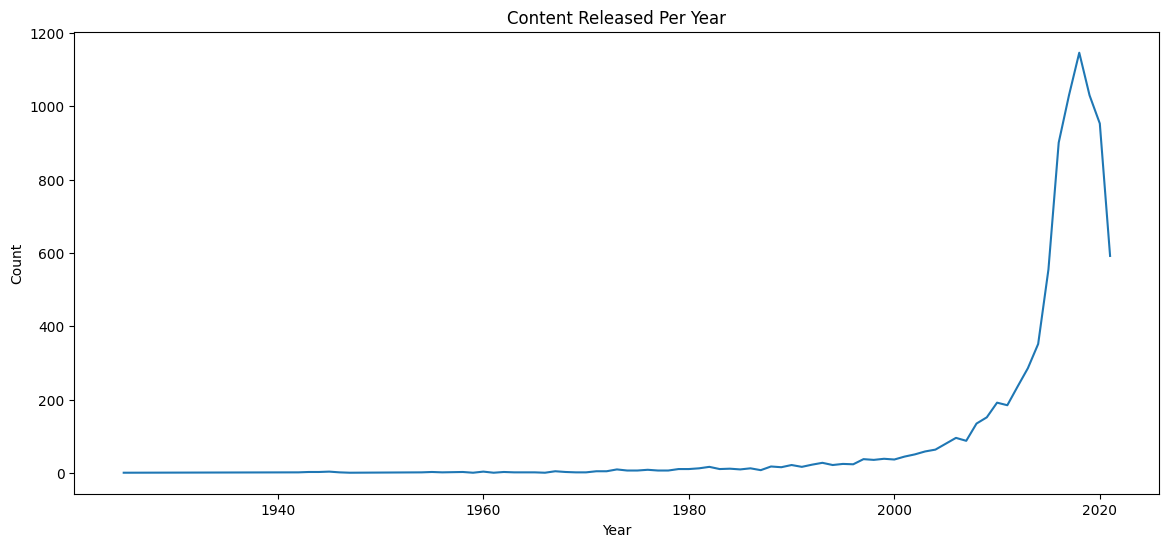

In [ ]:
df.head()
year_data = df['RELEASE_YEAR'].value_counts().sort_index()
plt.figure(figsize=(14,6))
plt.plot(year_data.index,year_data.values)
plt.title("Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

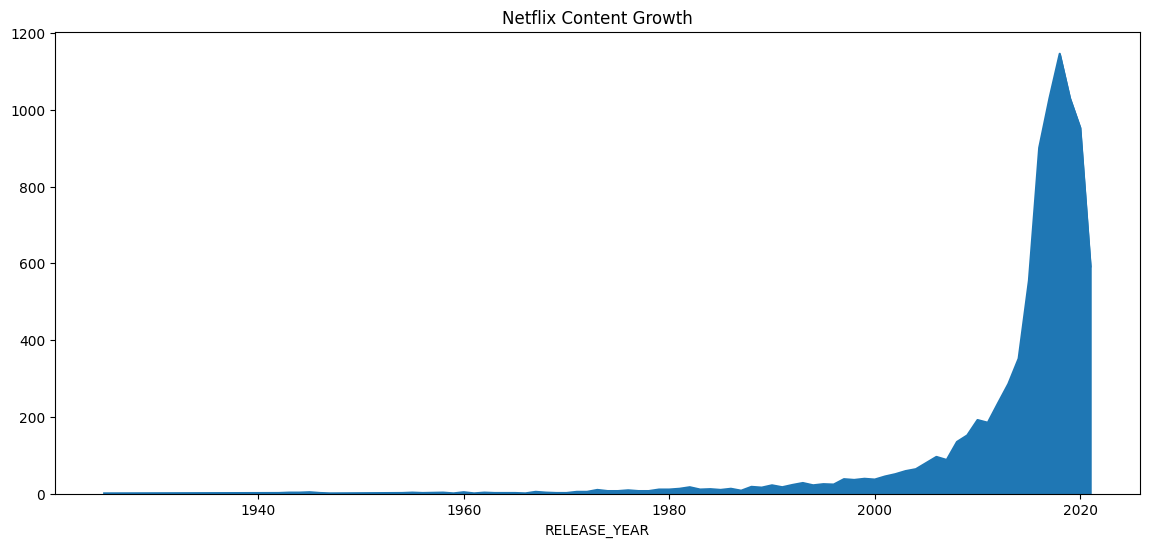

In [44]:

year_data = df['RELEASE_YEAR'].value_counts().sort_index()
year_data.plot(kind='area',figsize=(14,6))
plt.title("Netflix Content Growth")
plt.show()

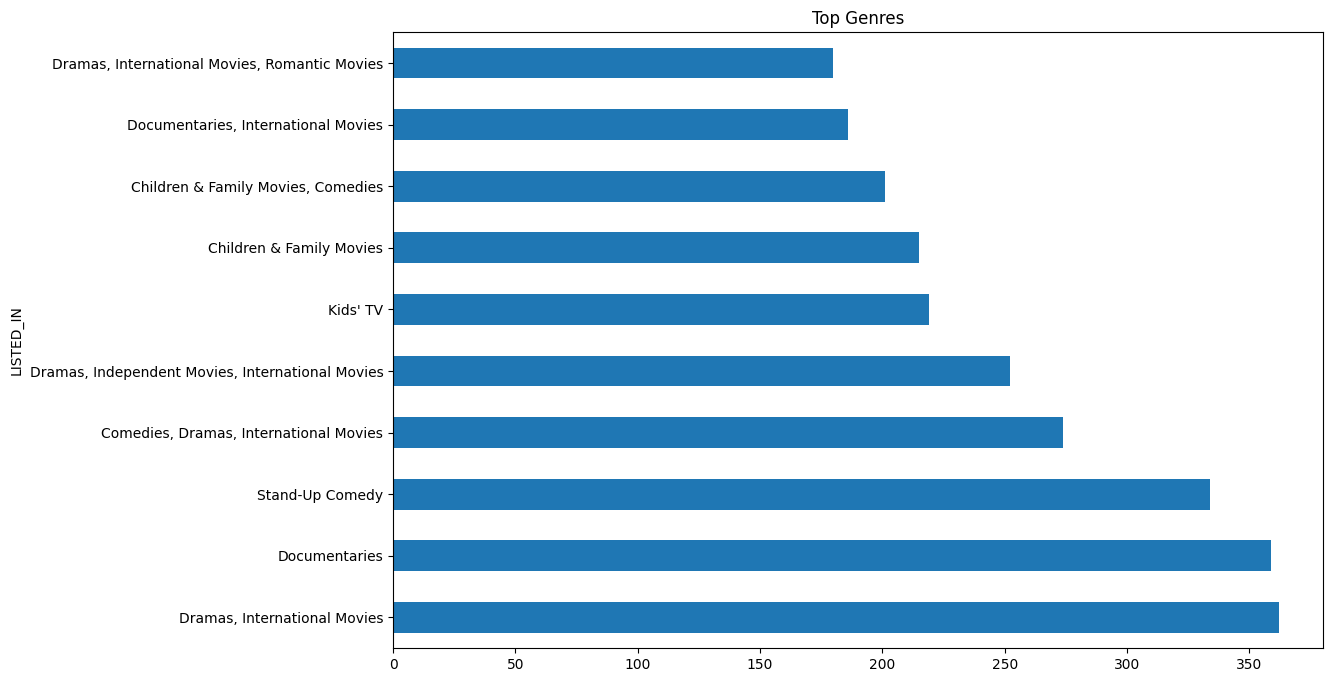

In [48]:
genre = df['LISTED_IN'].explode()
plt.figure(figsize=(12,8))
genre.value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()


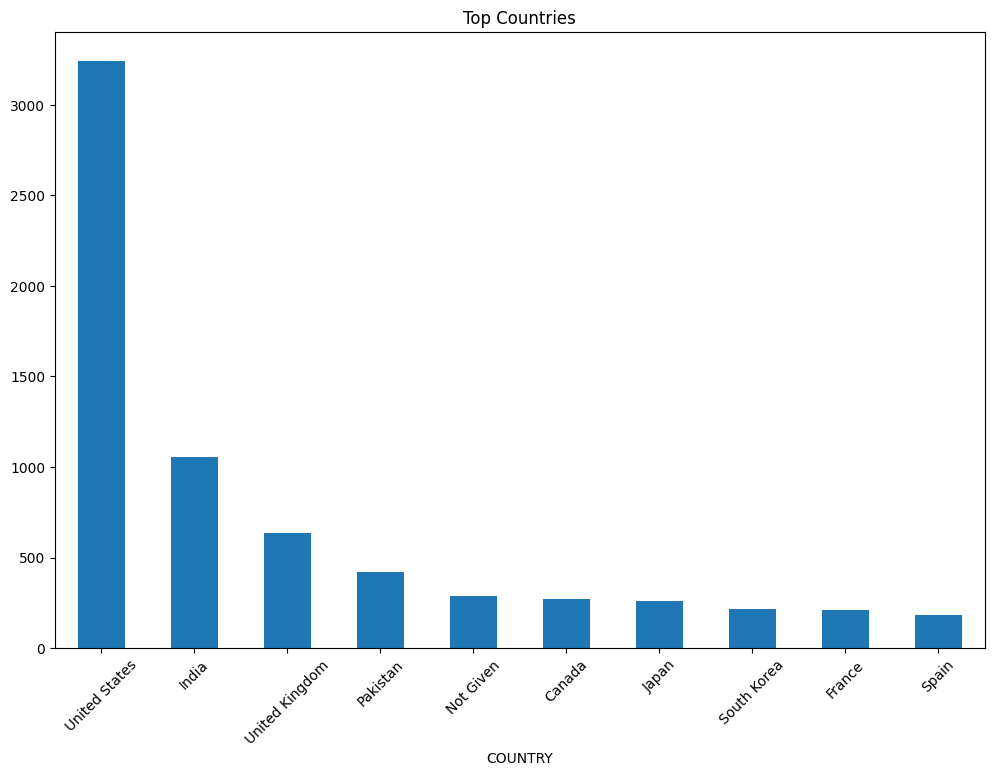

In [ ]:
country = df['COUNTRY'].str.split(',').explode()
plt.figure(figsize=(12,8))
country.value_counts().head(10).plot(kind='bar')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()

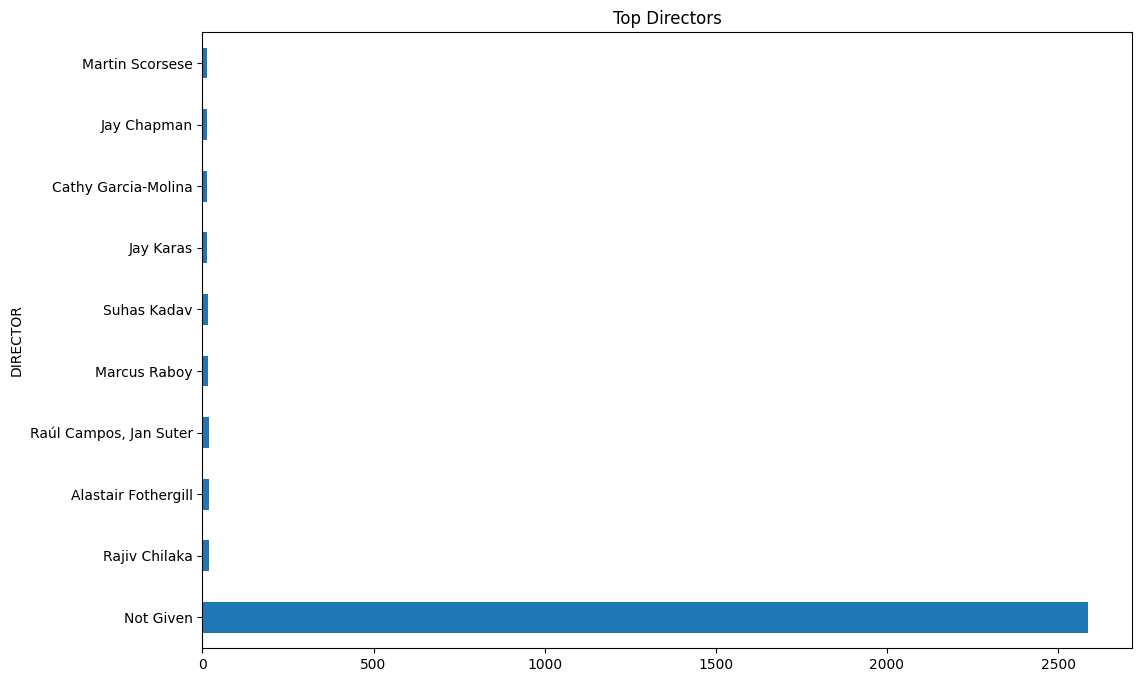

In [50]:
plt.figure(figsize=(12,8))
df['DIRECTOR'].value_counts().head(10).plot(kind='barh')
plt.title("Top Directors")
plt.show()

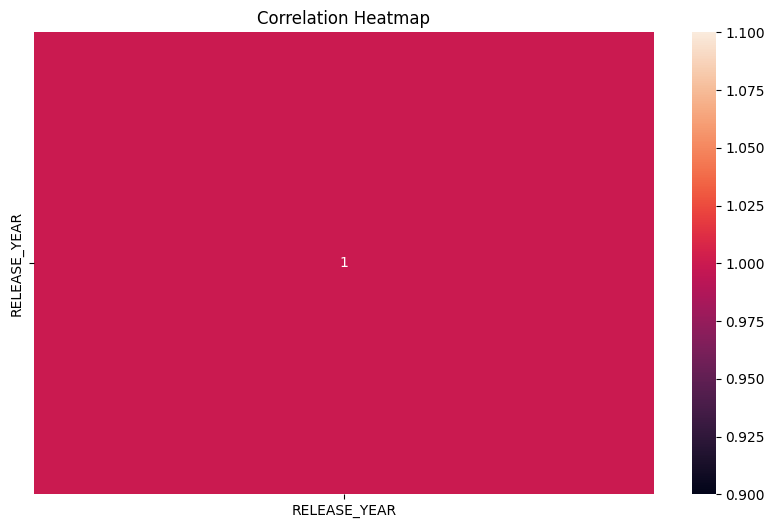

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()